## Step 0: Imports

In [1]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 150
BATCH_SIZE = 32
NUM_CLASSES = 4


## Step 1: Download Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

train_dir = os.path.join(path, "Training")
test_dir = os.path.join(path, "Testing")

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists :", os.path.exists(test_dir))

classes = sorted(os.listdir(train_dir))
print("Classes:", classes)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
Train dir exists: True
Test dir exists : True
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Step 1.5: Verify Download is Complete (run this every time!)


In [3]:
print(f"{'Class':<12} | {'Train':>6} | {'Test':>6}")
print("-" * 32)
for c in classes:
    n_train = len(os.listdir(os.path.join(train_dir, c)))
    n_test = len(os.listdir(os.path.join(test_dir, c)))
    print(f"{c:<12} | {n_train:>6} | {n_test:>6}")


Class        |  Train |   Test
--------------------------------
glioma       |   1400 |    400
meningioma   |   1400 |    400
notumor      |   1400 |    400
pituitary    |   1400 |    400


## Step 2: Data Generators — Augmentation on Train, Clean on Validation

In [4]:
train_aug_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
)

val_clean_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_aug_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_data = val_clean_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

class_indices = train_data.class_indices
class_names = {v: k for k, v in class_indices.items()}
print("class_indices:", class_indices)

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=2)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
class_indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Step 3: Class Weights

In [5]:
unique_classes = np.unique(train_data.classes)
weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_data.classes,
)
class_weight_dict = dict(zip(unique_classes, weights_arr))
print("Class weights:", class_weight_dict)


Class weights: {np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}


## Step 4: Build the Model (MobileNetV2 base, frozen for now)

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # Phase 1: keep ImageNet features frozen

model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12964\2234893450.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,068 (9.89 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Step 5: Phase 1 — Train the Top Layers (base frozen)


In [7]:
phase1_checkpoint = ModelCheckpoint(
    "phase1_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
)
phase1_early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
)

history_phase1 = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    class_weight=class_weight_dict,
    callbacks=[phase1_checkpoint, phase1_early_stop],
)


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 60s 401ms/step - accuracy: 0.7973 - loss: 0.5940 - val_accuracy: 0.8232 - val_loss: 0.5005
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 330ms/step - accuracy: 0.8712 - loss: 0.3853 - val_accuracy: 0.8321 - val_loss: 0.5043
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 383ms/step - accuracy: 0.8757 - loss: 0.3319 - val_accuracy: 0.8625 - val_loss: 0.4643
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 392ms/step - accuracy: 0.8897 - loss: 0.2918 - val_accuracy: 0.8705 - val_loss: 0.4072
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 380ms/step - accuracy: 0.9031 - loss: 0.2653 - val_accuracy: 0.8857 - val_loss: 0.3847
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 318ms/step - accuracy: 0.9080 - loss: 0.2466 - val_accuracy: 0.9018 - val_loss: 0.3323
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.9208 - loss: 0.2123 - val_accuracy: 0.8821 - val_loss: 0.3632
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 368ms/step - accuracy: 0.9134 - loss: 0

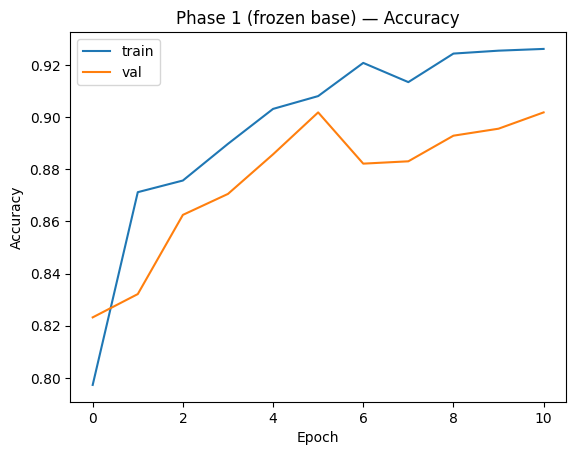

In [8]:
plt.plot(history_phase1.history['accuracy'], label='train')
plt.plot(history_phase1.history['val_accuracy'], label='val')
plt.title("Phase 1 (frozen base) — Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.show()


In [9]:
# Make sure we continue from the BEST phase-1 checkpoint, not just
# wherever training happened to stop.
model = load_model("phase1_best.keras")
base_model = model.layers[0]   # re-grab the MobileNetV2 layer reference
print("Loaded best phase-1 model.")


Loaded best phase-1 model.


## Step 6: Phase 2 — Fine-Tune the ENTIRE MobileNetV2

In [10]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


In [14]:
final_checkpoint = ModelCheckpoint(
    "brain_tumor_model_final.keras",   # <-- this is the file your app should load
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
)
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

history_phase2 = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    class_weight=class_weight_dict,
    callbacks=[final_checkpoint, early_stop, reduce_lr],
)


Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.8277 - loss: 0.4779 - val_accuracy: 0.8589 - val_loss: 0.5422 - learning_rate: 1.0000e-05
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 374s 3s/step - accuracy: 0.8487 - loss: 0.4135 - val_accuracy: 0.8438 - val_loss: 0.6030 - learning_rate: 1.0000e-05
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.8690 - loss: 0.3580 - val_accuracy: 0.8527 - val_loss: 0.5699 - learning_rate: 1.0000e-05
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.8857 - loss: 0.3071 - val_accuracy: 0.8446 - val_loss: 0.5727 - learning_rate: 1.0000e-05
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.8971 - loss: 0.2877 - val_accuracy: 0.8321 - val_loss: 0.5999 - learning_rate: 5.0000e-06
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 453s 3s/step - accuracy: 0.9018 - loss: 0.2621 - val_accuracy: 0.8259 - val_loss: 0.6025 - learning_rate: 5.0000e-06
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 405s 3s/step - acc

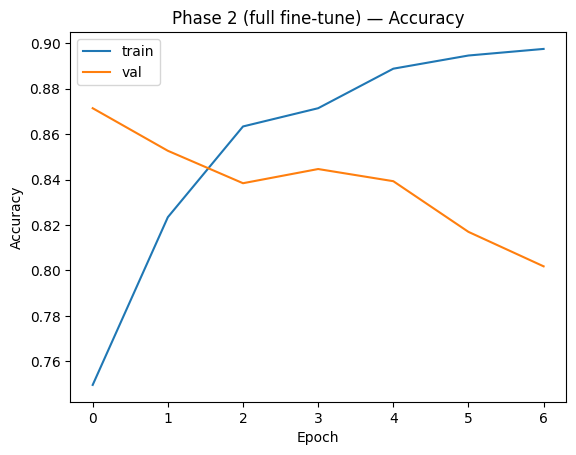

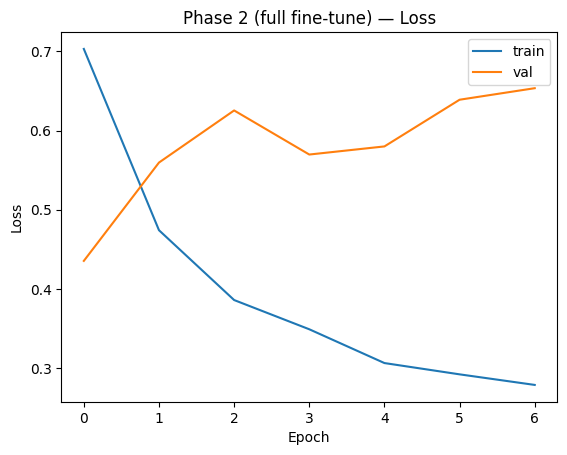

In [12]:
plt.plot(history_phase2.history['accuracy'], label='train')
plt.plot(history_phase2.history['val_accuracy'], label='val')
plt.title("Phase 2 (full fine-tune) — Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

plt.plot(history_phase2.history['loss'], label='train')
plt.plot(history_phase2.history['val_loss'], label='val')
plt.title("Phase 2 (full fine-tune) — Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.show()


In [13]:
# Reload the actual best-saved file, so we evaluate exactly what got
# written to disk (and what your app will load).
model = load_model("brain_tumor_model_final.keras")
print("Saved & reloaded: brain_tumor_model_final.keras")


Saved & reloaded: brain_tumor_model_final.keras


## Step 7: Evaluate on Test Set — Per-Class Breakdown

In [15]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.8356 - loss: 0.5973
Test Accuracy: 0.8356
Test Loss    : 0.5973


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step
              precision    recall  f1-score   support

      glioma       0.81      0.80      0.80       400
  meningioma       0.76      0.72      0.74       400
     notumor       0.97      0.90      0.94       400
   pituitary       0.81      0.92      0.86       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



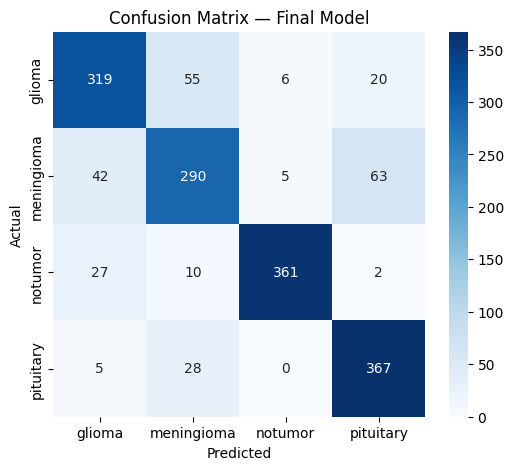

In [16]:
test_data.reset()
y_true = test_data.classes
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=list(class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_indices.keys(),
            yticklabels=class_indices.keys())
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Final Model")
plt.show()


In [17]:
pred_counts = np.bincount(y_pred, minlength=NUM_CLASSES)
true_counts = np.bincount(y_true, minlength=NUM_CLASSES)

print(f"{'Class':<12} | {'Actual':>7} | {'Predicted':>9}")
print("-" * 35)
for idx, cname in class_names.items():
    print(f"{cname:<12} | {true_counts[idx]:>7} | {pred_counts[idx]:>9}")


Class        |  Actual | Predicted
-----------------------------------
glioma       |     400 |       393
meningioma   |     400 |       383
notumor      |     400 |       372
pituitary    |     400 |       452


## Step 8: Sanity Check — Predict a Random Test Image


In [18]:
def predict_image(img_path, model=model):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))  # RGB
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], probs

sample_class = random.choice(classes)
sample_folder = os.path.join(test_dir, sample_class)
sample_img = random.choice(os.listdir(sample_folder))
sample_path = os.path.join(sample_folder, sample_img)

pred_label, pred_probs = predict_image(sample_path)
print("Actual class   :", sample_class)
print("Predicted class:", pred_label)
print("Probabilities  :", dict(zip(class_indices.keys(), pred_probs)))


Actual class   : notumor
Predicted class: notumor
Probabilities  : {'glioma': np.float32(3.3193878e-08), 'meningioma': np.float32(7.748063e-07), 'notumor': np.float32(0.9999993), 'pituitary': np.float32(5.543851e-12)}
